# Clustering Inference Pipeline

Loads the trained KMeans model and cluster→resolution mapping, assigns clusters to the
**held-out test questions**, and evaluates the accuracy vs. cost trade-off out-of-sample.

The test rows are the ones marked `test` in `data_split.csv`, written by the training
notebook. Neither the clusters nor the resolution mapping were fitted on them.

**Inputs**: trained model (`.pkl`), resolution mapping (`.csv`), split assignment (`.csv`), dataset (`.jsonl`), ground-truth scores (`.xlsx`)
**Outputs**: per-question predictions (`doc_id, cluster, resolution`), accuracy vs. cost analysis

In [1]:
# Setup: Determine project root
from pathlib import Path
import sys

# Find project root (contains pyproject.toml)
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not find project root (pyproject.toml)")
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")
sys.path.insert(0, str(PROJECT_ROOT))

Project root: /home/das/poli/redes-neurais-e-dl/scale-wise-optimizer


---
## 0 · Configuration

In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
MODEL_PATH           = str(PROJECT_ROOT / 'clustering/training/artifacts/clustering_model.pkl')                   # trained KMeans model
MAPPING_PATH         = str(PROJECT_ROOT / 'clustering/training/results/qwen3/cluster_resolution_mapping.csv')         # cluster → resolution lookup
SPLIT_PATH           = str(PROJECT_ROOT / 'clustering/training/results/qwen3/data_split.csv')                         # doc_id → train/test assignment
DATASET              = str(PROJECT_ROOT / 'benchmarks/seedbench_2_plus/test_questions.jsonl')                   # full benchmark (one JSON per line, must have 'input' and 'doc_id')
SCORES_FILE          = str(PROJECT_ROOT / 'benchmarks/seedbench_2_plus/qwen3_resolution_analysis.xlsx')  # ground-truth scores per resolution
SCORES_SHEET         = 'Consolidated_Scores'

# ── Resolution tokens (must match training) ──────────────────────────────────
RESOLUTIONS = ['2000', '12500', '25000', '50000', '100000',
               '150000', '250000', '400000', '600000', '800000']

# ── Strategy column from the mapping to use as the default recommendation ────
#    Options: 'best_resolution', 'efficient_res_95pct', 'efficient_res_99pct'
STRATEGY = 'efficient_res_95pct'

# ── Output ───────────────────────────────────────────────────────────────────
PREDICTIONS_OUTPUT = str(PROJECT_ROOT / 'clustering/inference/results/qwen3/test_predictions.csv')

---
## 1 · Load artifacts

In [3]:
import json, re, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer

sns.set_style('whitegrid')
%matplotlib inline

# ── Load trained model ────────────────────────────────────────────────────────
with open(MODEL_PATH, 'rb') as f:
    artefacts = pickle.load(f)

kmeans          = artefacts['kmeans']
embedding_model = artefacts['embedding_model']
optimal_k       = artefacts['optimal_k']

print(f'KMeans loaded  ·  K = {optimal_k}  ·  embedding model = {embedding_model}')

# ── Load cluster → resolution mapping ─────────────────────────────────────────
df_mapping = pd.read_csv(MAPPING_PATH)
print(f'Mapping loaded ·  {len(df_mapping)} clusters')

# ── Load the train/test assignment produced by the training notebook ──────────
df_split = pd.read_csv(SPLIT_PATH)
test_ids = set(df_split.loc[df_split['split'] == 'test', 'doc_id'])
print(f'Split loaded   ·  {len(test_ids)} held-out test questions')
df_mapping.head()

/home/das/poli/redes-neurais-e-dl/scale-wise-optimizer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KMeans loaded  ·  K = 30  ·  embedding model = all-MiniLM-L6-v2
Mapping loaded ·  30 clusters
Split loaded   ·  456 held-out test questions


,cluster,n_questions,best_resolution,best_accuracy,efficient_res_95pct,acc_at_95pct,efficient_res_99pct,acc_at_99pct
0,0,15,600000,0.866667,600000,0.866667,600000,0.866667
1,1,107,800000,0.672897,400000,0.663551,800000,0.672897
2,2,34,800000,0.852941,800000,0.852941,800000,0.852941
3,3,63,250000,0.587302,250000,0.587302,250000,0.587302
4,4,110,800000,0.681818,400000,0.654545,800000,0.681818


---
## 2 · Load & preprocess the held-out test data

In [4]:
# ── Read the benchmark, then keep only the held-out rows ──────────────────────
with open(DATASET, 'r', encoding='utf-8') as f:
    df_all = pd.DataFrame([json.loads(line) for line in f])

df_test = df_all[df_all['doc_id'].isin(test_ids)].reset_index(drop=True)
assert len(df_test) == len(test_ids), 'split file references doc_ids missing from the dataset'

# ── Clean question text (same transform as training) ──────────────────────────
def clean_input(text: str) -> str:
    text = text.replace("Answer with the option's letter from the given choices directly.", '').strip()
    match = re.search(r'\n[A-D]\.\s', text)
    return text[:match.start()].strip() if match else text

df_test['question_stem'] = df_test['input'].apply(clean_input)

# ── Merge ground-truth scores (for evaluation only) ───────────────────────────
df_scores = pd.read_excel(SCORES_FILE, sheet_name=SCORES_SHEET)
df_test = df_test.merge(df_scores[['doc_id'] + RESOLUTIONS], on='doc_id', how='left')

print(f'Held-out test set: {len(df_test)} of {len(df_all)} questions '
      f'({len(df_test) / len(df_all):.0%})')

Held-out test set: 456 of 2277 questions (20%)


---
## 3 · Predict clusters & assign resolutions

In [5]:
# ── Embed ─────────────────────────────────────────────────────────────────────
encoder = SentenceTransformer(embedding_model)
embeddings = encoder.encode(df_test['question_stem'].tolist(), show_progress_bar=True)
print(f'Embeddings: {embeddings.shape}')

# ── Predict (uses the trained centroids, no re-fitting) ───────────────────────
df_test['cluster'] = kmeans.predict(embeddings)

# ── Lookup resolution from mapping ────────────────────────────────────────────
resolution_lookup = df_mapping.set_index('cluster')[STRATEGY].to_dict()
df_test['resolution'] = df_test['cluster'].map(resolution_lookup)

print(f'Assigned clusters: {df_test["cluster"].nunique()} unique')
print(f'Strategy: {STRATEGY}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1896.05it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 15/15 [00:00<00:00, 59.71it/s]

Embeddings: (456, 384)
Assigned clusters: 29 unique
Strategy: efficient_res_95pct


---
## 4 · Save predictions

In [6]:
# ── Final output: question_id → cluster → resolution ──────────────────────────
os.makedirs(os.path.dirname(PREDICTIONS_OUTPUT), exist_ok=True)

id_col = 'question_id' if 'question_id' in df_test.columns else 'doc_id'
df_predictions = df_test[[id_col, 'cluster', 'resolution']].copy()
df_predictions.to_csv(PREDICTIONS_OUTPUT, index=False)

print(f'Saved {len(df_predictions)} predictions → {PREDICTIONS_OUTPUT}')
df_predictions.head(10)

Saved 456 predictions → /home/das/poli/redes-neurais-e-dl/scale-wise-optimizer/clustering/inference/results/qwen3/test_predictions.csv


,doc_id,cluster,resolution
0,1,3,250000
1,4,3,250000
2,13,1,400000
3,14,3,250000
4,20,1,400000
5,21,3,250000
6,27,1,400000
7,32,1,400000
8,35,19,250000
9,40,19,250000


---
## 5 · Evaluation — Cluster distribution

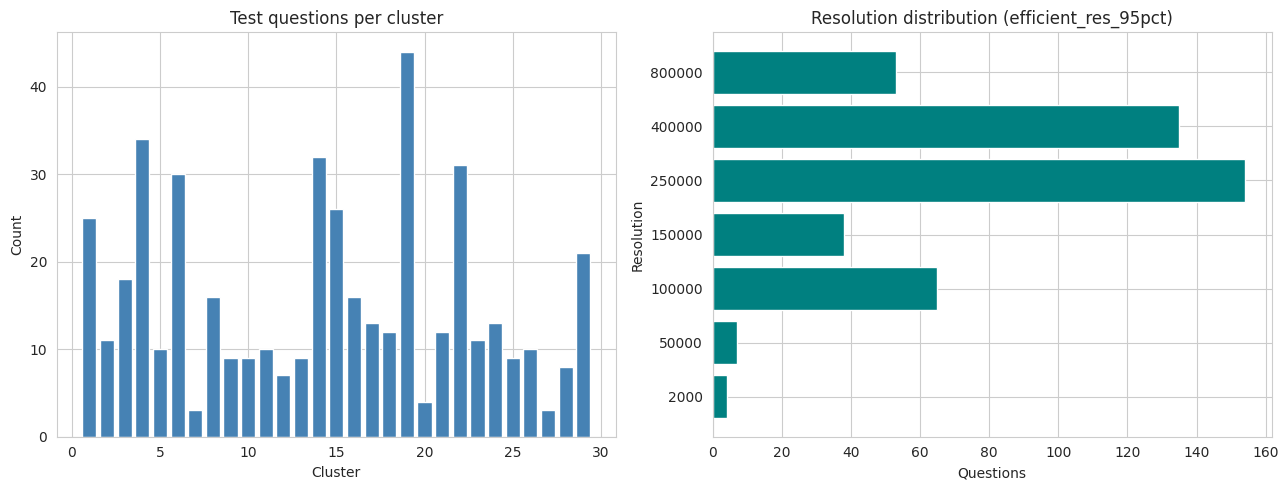

In [7]:
cluster_counts = df_test['cluster'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
ax1.bar(cluster_counts.index, cluster_counts.values, color='steelblue', edgecolor='white')
ax1.set_xlabel('Cluster'); ax1.set_ylabel('Count')
ax1.set_title('Test questions per cluster')

# Assigned resolution distribution
res_counts = df_test['resolution'].astype(str).value_counts().sort_index(key=lambda x: x.astype(int))
ax2.barh(res_counts.index, res_counts.values, color='teal', edgecolor='white')
ax2.set_xlabel('Questions'); ax2.set_ylabel('Resolution')
ax2.set_title(f'Resolution distribution ({STRATEGY})')

plt.tight_layout()
plt.show()

---
## 6 · Evaluation — Accuracy vs. computational cost (out-of-sample)

Every number below is computed on questions that were excluded from both the KMeans fit
and the per-cluster resolution selection.

In [8]:
MAX_RES = max(int(r) for r in RESOLUTIONS)
n_test  = len(df_test)

def _strategy_metrics(df, res_series):
    """Weighted accuracy and relative cost for a given per-question resolution series."""
    correct = sum(
        df.iloc[i][str(int(res_series.iloc[i]))] for i in range(len(df))
    )
    cost = res_series.astype(int).sum()
    return correct / n_test, cost / (n_test * MAX_RES) * 100

# ── Fixed-resolution baselines ────────────────────────────────────────────────
rows = []
for res in RESOLUTIONS:
    acc  = df_test[res].mean()
    cost = int(res) / MAX_RES * 100
    rows.append({'strategy': f'Fixed {res}', 'accuracy': acc, 'cost_pct': cost})

df_fixed = pd.DataFrame(rows)

# ── Cluster-based strategies ──────────────────────────────────────────────────
mapping_dict = df_mapping.set_index('cluster')
cluster_strat_rows = []

for label, col in [('Best per cluster', 'best_resolution'),
                    ('Efficient (95%)',  'efficient_res_95pct'),
                    ('Efficient (99%)',  'efficient_res_99pct')]:
    res_per_q = df_test['cluster'].map(mapping_dict[col].to_dict()).astype(str)
    acc, cost = _strategy_metrics(df_test, res_per_q)
    cluster_strat_rows.append({'strategy': label, 'accuracy': acc, 'cost_pct': cost})

df_cluster_strat = pd.DataFrame(cluster_strat_rows)
df_all = pd.concat([df_fixed, df_cluster_strat], ignore_index=True)

print('Strategy comparison on test set:')
df_all.round(4)

Strategy comparison on test set:


,strategy,accuracy,cost_pct
0,Fixed 2000,0.4671,0.2500
1,Fixed 12500,0.4715,1.5625
2,Fixed 25000,0.4781,3.1250
3,Fixed 50000,0.5526,6.2500
4,Fixed 100000,0.6031,12.5000
5,Fixed 150000,0.6469,18.7500
6,Fixed 250000,0.6886,31.2500
7,Fixed 400000,0.7149,50.0000
8,Fixed 600000,0.7412,75.0000
9,Fixed 800000,0.7368,100.0000


Graph saved to /home/das/poli/redes-neurais-e-dl/scale-wise-optimizer/clustering/inference/results/final_graph.pdf


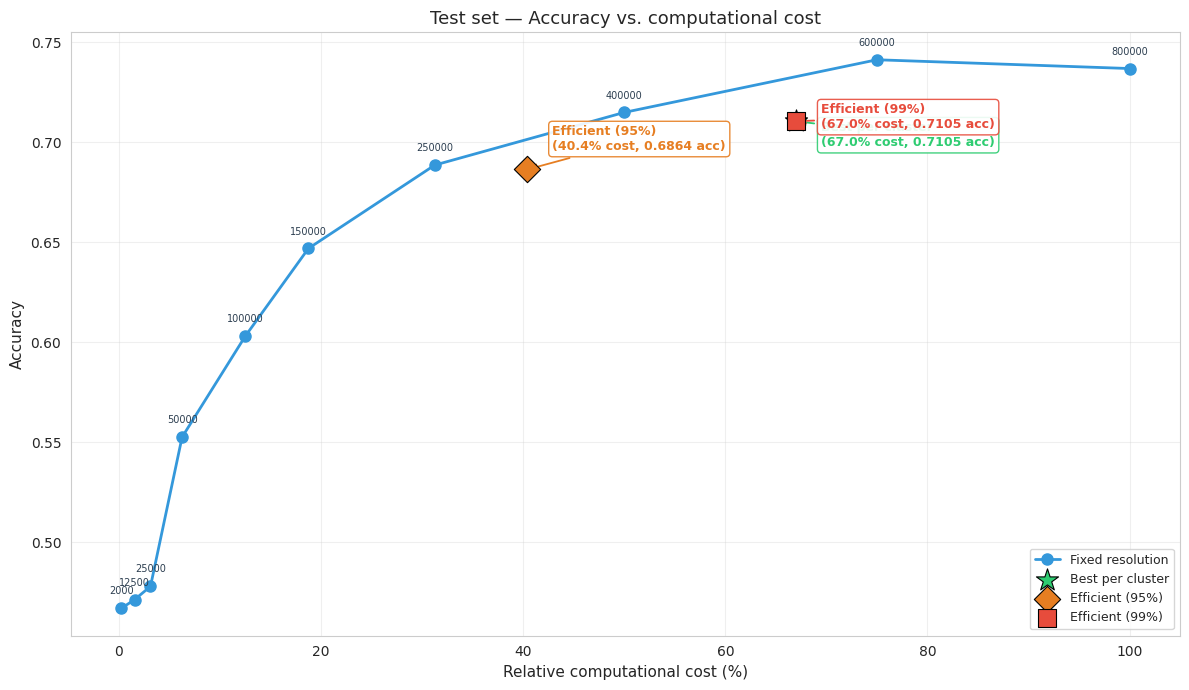

In [9]:
GRAPH_PDF = str(PROJECT_ROOT / 'clustering/inference/results/final_graph.pdf')

fig, ax = plt.subplots(figsize=(12, 7))

# ── Fixed-resolution curve ────────────────────────────────────────────────────
ax.plot(df_fixed['cost_pct'], df_fixed['accuracy'],
        'o-', color='#3498db', lw=2, ms=8, label='Fixed resolution', zorder=3)

for _, r in df_fixed.iterrows():
    ax.annotate(r['strategy'].replace('Fixed ', ''),
                (r['cost_pct'], r['accuracy']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=7, color='#2c3e50')

# ── Cluster strategies ────────────────────────────────────────────────────────
style = {
    'Best per cluster': ('*',  '#2ecc71', 280),
    'Efficient (95%)':  ('D',  '#e67e22', 180),
    'Efficient (99%)':  ('s',  '#e74c3c', 180),
}

for _, r in df_cluster_strat.iterrows():
    mk, co, sz = style[r['strategy']]
    ax.scatter(r['cost_pct'], r['accuracy'],
               marker=mk, c=co, s=sz, zorder=5,
               edgecolors='black', linewidth=0.8, label=r['strategy'])
    ax.annotate(
        f"{r['strategy']}\n({r['cost_pct']:.1f}% cost, {r['accuracy']:.4f} acc)",
        (r['cost_pct'], r['accuracy']),
        textcoords='offset points',
        xytext=(18, -18) if 'Best' in r['strategy'] else (18, 14) if '95' in r['strategy'] else (18, -5),
        fontsize=9, fontweight='bold', color=co,
        arrowprops=dict(arrowstyle='->', color=co, lw=1.3),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=co, alpha=0.9))

ax.set_xlabel('Relative computational cost (%)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Test set — Accuracy vs. computational cost', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs(os.path.dirname(GRAPH_PDF), exist_ok=True)
plt.savefig(GRAPH_PDF)
print(f"Graph saved to {GRAPH_PDF}")
plt.show()

---
## 7 · Evaluation — Per-cluster accuracy on test set

In [10]:
# Accuracy per cluster at the assigned resolution vs. at max resolution
rows = []
for cid, grp in df_test.groupby('cluster'):
    assigned_res = str(int(grp['resolution'].iloc[0]))
    rows.append({
        'cluster': cid,
        'n_test': len(grp),
        'assigned_resolution': assigned_res,
        'acc_at_assigned': grp[assigned_res].mean(),
        'acc_at_max': grp[RESOLUTIONS[-1]].mean(),
    })

df_eval = pd.DataFrame(rows).sort_values('cluster')
df_eval['acc_gap'] = df_eval['acc_at_max'] - df_eval['acc_at_assigned']

print(f'Mean accuracy gap (max − assigned): {df_eval["acc_gap"].mean():.4f}')
df_eval.round(4)

Mean accuracy gap (max − assigned): 0.0634


,cluster,n_test,assigned_resolution,acc_at_assigned,acc_at_max,acc_gap
0,1,25,400000,0.7200,0.7200,0.0000
1,2,11,800000,0.9091,0.9091,0.0000
2,3,18,250000,0.5556,0.6667,0.1111
3,4,34,400000,0.7059,0.6471,-0.0588
4,5,10,250000,0.7000,0.6000,-0.1000
5,6,30,100000,0.5667,0.6667,0.1000
6,7,3,150000,0.6667,0.6667,0.0000
7,8,16,150000,0.7500,0.8125,0.0625
8,9,9,100000,0.4444,0.7778,0.3333
9,10,9,800000,0.8889,0.8889,0.0000


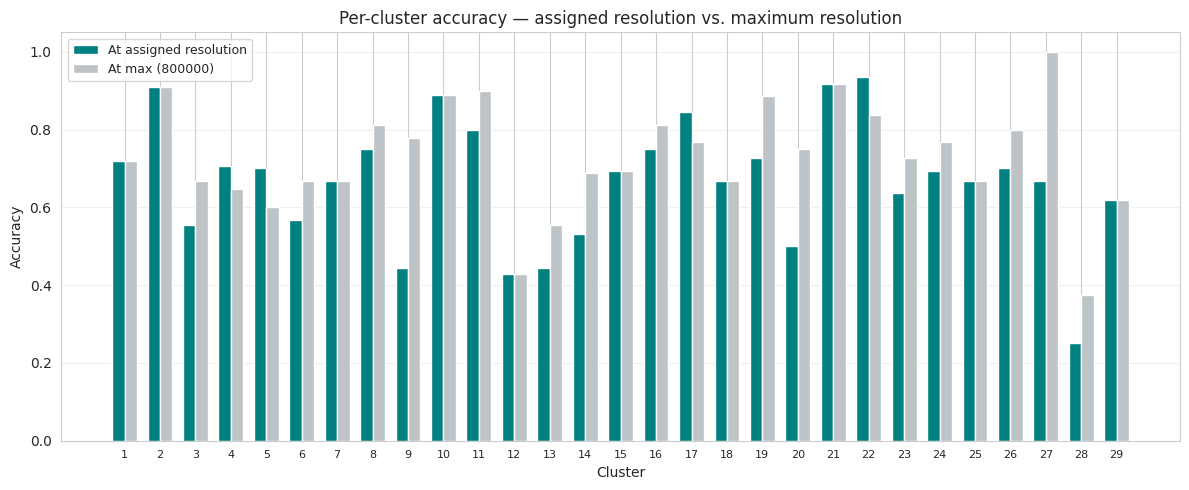

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(df_eval))
w = 0.35

ax.bar(x - w/2, df_eval['acc_at_assigned'], w, label='At assigned resolution', color='teal',   edgecolor='white')
ax.bar(x + w/2, df_eval['acc_at_max'],      w, label=f'At max ({RESOLUTIONS[-1]})', color='#bdc3c7', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(df_eval['cluster'], fontsize=8)
ax.set_xlabel('Cluster'); ax.set_ylabel('Accuracy')
ax.set_title('Per-cluster accuracy — assigned resolution vs. maximum resolution')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()